# 📝 Instrucciones: Predecir el coste del seguro médico de una persona

La importante compañía de seguros **4Geeks Insurance S.L.** quiere calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

---

## Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre `medical_insurance_cost.csv`. Puedes cargarlo en el código directamente desde el siguiente enlace:

[https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv](https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv)

O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

* **age.** Edad del beneficiario principal (numérico)
* **sex.** Género del beneficiario principal (categórico)
* **bmi.** Índice de masa corporal (numérico)
* **children.** Número de niños/dependientes cubiertos por un seguro médico (numérico)
* **smoker.** ¿Es fumador? (categórico)
* **region.** Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
* **charges.** Prima del seguro médico (numérico)

---

## Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en **train** y **test** como hemos visto en lecciones anteriores.

---

## Paso 3: Construye un modelo de regresión lineal
No es necesario que optimices los hiperparámetros. Comienza utilizando una definición por defecto y mejórala en el paso siguiente.

---

## Paso 4: Optimiza el modelo anterior
Después de entrenar el modelo, si los resultados no son satisfactorios, optimízalo si fuera posible.

In [210]:
#Importo todas las librerias que voy a necesitar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
# OJO!!!! las funciones create_factor_transf_and_json, train_prepare_test_data y train_print_model que son de creacion personal estan en utils
# (archivo que ya existia en el repositorio y no toque), para mantener la legibilidad de este jupiterlab.
import utils
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Lasso

In [211]:
# Cargamos el dataset
total_data = pd.read_csv('../data/raw/medical_insurance_cost.csv')
total_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [212]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'total_data': {len(total_data)}")

# Verificamos La Cantidad De Variables Por Tipos De Datos en total_data que son los datos que vamos a aplicar el EDA:
pd.Series.value_counts(total_data.dtypes)

Numero De Filas en 'total_data': 1338


str        3
int64      2
float64    2
Name: count, dtype: int64

In [213]:
print("------------------PORCENTAJE DE VALORES NULOS DEL total_data---------------------\n")
#Obtenemos que columnas tienen valores nulos y porcentage respectivamente
info_nulls = pd.DataFrame({
    '% Nullidad': total_data.isna().sum() / len(total_data) * 100
}).sort_values(by='% Nullidad', ascending=False)
info_nulls

------------------PORCENTAJE DE VALORES NULOS DEL total_data---------------------



,% Nullidad
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
charges,0.0


In [214]:
print("------------------PORCENTAJE DE VALORES UNICOS DEL total_data---------------------\n")
#Obtenemos que columnas tienen valores unicos y porcentage respectivamente
info_uniques = pd.DataFrame({
    'Valores Únicos': total_data.nunique(),
    'Total Filas': len(total_data),
    '% Unicidad': (total_data.nunique() / len(total_data)) * 100
}).sort_values(by='% Unicidad', ascending=False)
info_uniques

------------------PORCENTAJE DE VALORES UNICOS DEL total_data---------------------



,Valores Únicos,Total Filas,% Unicidad
charges,1337,1338,99.925262
bmi,548,1338,40.956652
age,47,1338,3.512706
children,6,1338,0.448430
region,4,1338,0.298954
sex,2,1338,0.149477
smoker,2,1338,0.149477


# Analisis (Hasta Ahora):
* Tenemos un dataframe total_data con 7 columnas y 1338  filas
* 2 columnas son int64, 3 str y 2 float64
* Ninguna de esas columnas tienen valores nulos.
* El Target es **charges.** Prima del seguro médico (numérico).
* Charges y bmi son las que tienen mas unicidad pero charges es nuestro target, hay que analizar si bmi nos arroja info relevante.

In [215]:
# Revisar Los Posibles Datos Categóricos
total_data.select_dtypes(include = ['str']).columns

Index(['sex', 'smoker', 'region'], dtype='str')

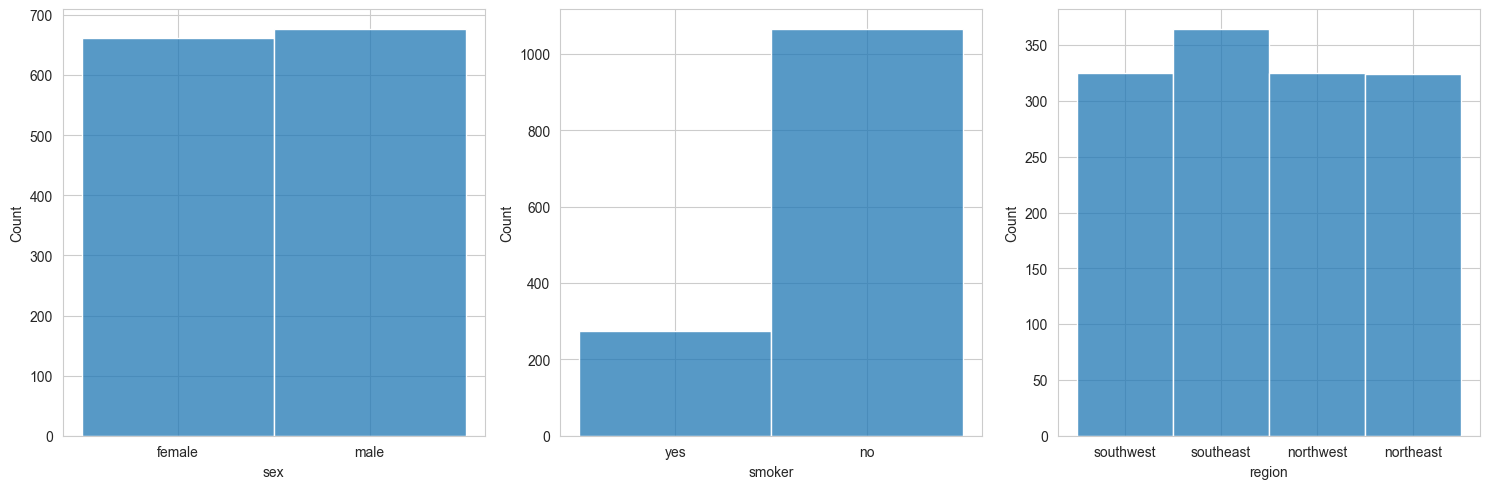

In [216]:
#Creamos Un Histograma Múltiple
fig = plt.figure(figsize = (15, 5))
axis = gridspec.GridSpec(1, 3, figure = fig)

axis1 = fig.add_subplot(axis[0, 0]); sns.histplot(data = total_data, x='sex', ax = axis1)
axis2 = fig.add_subplot(axis[0, 1]); sns.histplot(data = total_data, x='smoker', ax = axis2)
axis3 = fig.add_subplot(axis[0, 2]); sns.histplot(data = total_data, x='region', ax = axis3)

#Ajustar Layaut
plt.tight_layout()
#Mostramos El Plot
plt.show()

In [217]:
# Factorizamos
utils.create_factor_transf_and_json("sex", total_data,target_column="charges", folder_name="SeguroEjericio02")
utils.create_factor_transf_and_json("smoker", total_data,target_column="charges", folder_name="SeguroEjericio02")
utils.create_factor_transf_and_json("region", total_data,target_column="charges",folder_name= "SeguroEjericio02")
total_data.head()

Json guardado en: ../data/processed/factories/SeguroEjericio02\sex_factory_rules.json
Json guardado en: ../data/processed/factories/SeguroEjericio02\smoker_factory_rules.json
Json guardado en: ../data/processed/factories/SeguroEjericio02\region_factory_rules.json


,age,bmi,children,sex_factor,smoker_factor,region_factor,charges
0,19,27.900,0,0,0,0,16884.92400
1,18,33.770,1,1,1,1,1725.55230
2,28,33.000,3,1,1,1,4449.46200
3,33,22.705,0,1,1,2,21984.47061
4,32,28.880,0,1,1,2,3866.85520


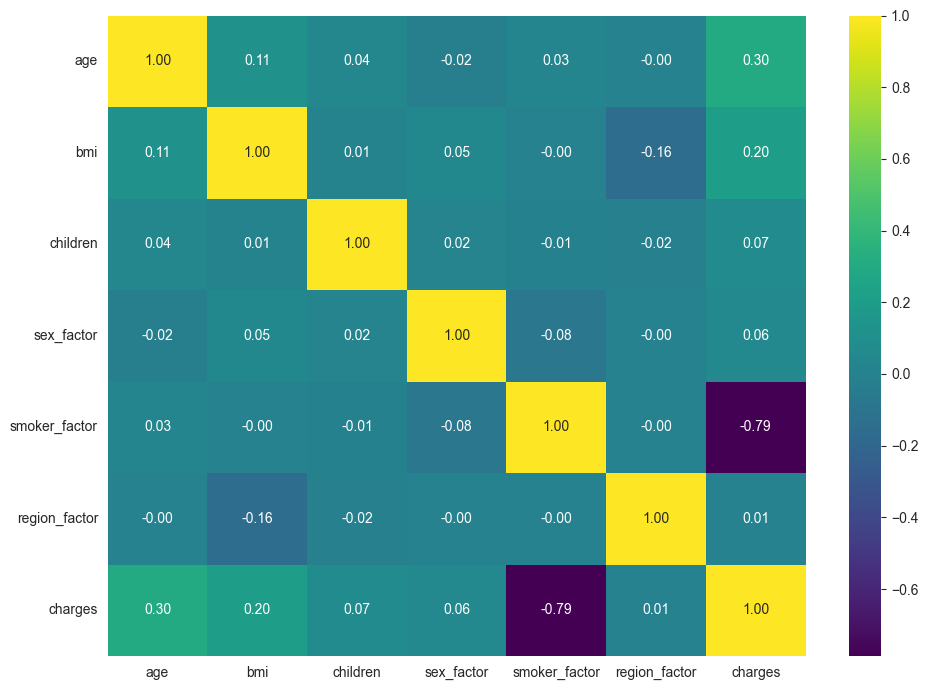

In [218]:
#Ahora que hemos filtrado factorizamos dibujamos un heatmap
cols_num = list(total_data.select_dtypes(include = ['number']).columns)
fig, ax = plt.subplots(figsize = (10,  7))
sns.heatmap(total_data[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis",ax = ax)
plt.tight_layout()
plt.show()

In [219]:
cols_num

['age',
 'bmi',
 'children',
 'sex_factor',
 'smoker_factor',
 'region_factor',
 'charges']

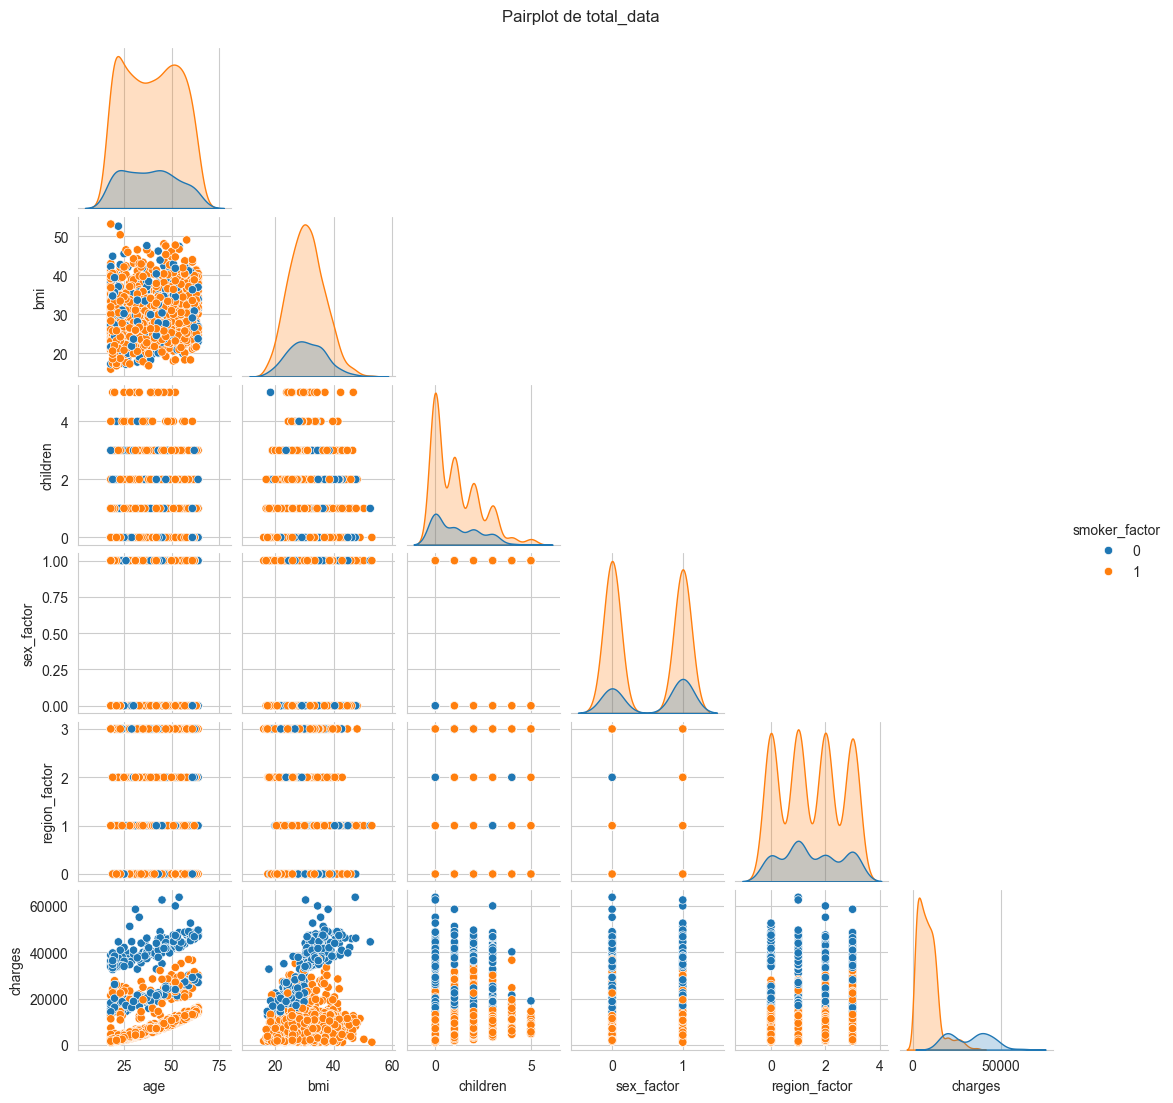

In [220]:
# Procedemos a graficar un pairplot para ver si hay pendientes, probe graficandolo solo pero no se veia nada, entonces lo hice con el hue de smoker_factor.
g = sns.pairplot(total_data, diag_kind="kde",hue="smoker_factor", corner=True, height=1.8)
plt.suptitle("Pairplot de total_data", y=1.02)
plt.show()

# Analisis hasta ahora
* el heatmap nos muestra una altisima correlacion inversa de charges con smoke_factor, de -0.79, aunque podria parecer redundante, tenemos pocas variables, asi que esta sera nuestro indicador estrella.
* ademas el bmi y el age tienen una correlacion de 0.20 y 0.30 respectivamente, se haran pruebas con estos dos indicadores incluidos tambien.
* en el pairplot vemos a cada variable distinguida por 0(Puntos Azules) que representan a los fumadores, los 1(Puntos naranja) representa los no fumadores.
* en las variables factorizadas es dificil que veamos una pendiente no vertical porque presisamente antes eran categorizas, pero en age y bmi vemos como los puntos azules de los fumadores forman una pendiente hacia arriba.

In [221]:
#Eliminamos las columnas que no tenian una pendiente clara. 
total_data.drop(["children","sex_factor","region_factor"],  axis = 1,  inplace = True)
total_data.head()

,age,bmi,smoker_factor,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,1,4449.46200
3,33,22.705,1,21984.47061
4,32,28.880,1,3866.85520


In [222]:
#generamos los datos de train y prueba pero con las columnas eliminadas.
x_train_out, x_test_out, y_train_out, y_test_out, x_train_no_out, x_test_no_out,y_train_no_out, y_test_no_out = utils.train_prepare_test_data(total_data, "charges", "SeguroEjericio02", scaler_type = 1)
x_train_out.head()

,age,bmi,smoker_factor
560,0.472227,-1.756525,0.508747
1285,0.543313,-1.033082,0.508747
1142,0.898745,-0.943687,0.508747
969,-0.025379,0.622393,0.508747
486,1.040918,-1.504893,0.508747


In [223]:
#entrenamos el modelo de regresion lineal y obtenemos las predicciones, el r2 y el mse tanto con outliers como sin outliers
preds_out, preds_no_out, r2_out, r2_no_out, mse_out, mse_no_out = utils.train_print_model(x_train_out, x_test_out, y_train_out, y_test_out, x_train_no_out, x_test_no_out,y_train_no_out, y_test_no_out, type_model = "lr")
print(f"R2 sin outliers: {r2_no_out}")
print(f"R2 con outliers: {r2_out}")
print(f"MSE sin outliers: {mse_no_out}")
print(f"MSE con outliers: {mse_out}")

R2 sin outliers: 0.15056913421073626
R2 con outliers: 0.7776932310583375
MSE sin outliers: 131873064.40374209
MSE con outliers: 34512843.880227886


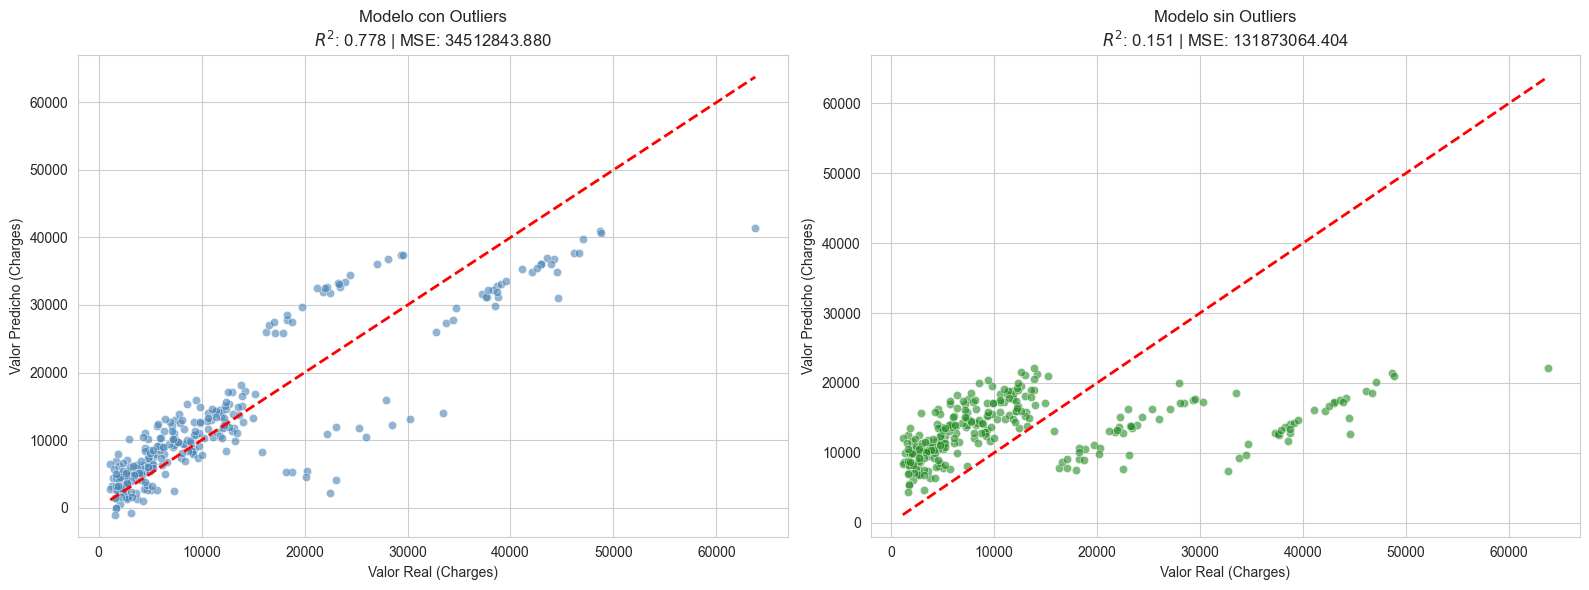

In [224]:
# 1. Configurar el estilo visual
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: con outliers ---
sns.scatterplot(x=y_test_out, y=preds_out, ax=ax1, alpha=0.6, color="steelblue")
# Linea de referencia (predicción perfecta)
ax1.plot([y_test_out.min(), y_test_out.max()], [y_test_out.min(), y_test_out.max()], 'r--', lw=2)
ax1.set_title(f"Modelo con Outliers\n$R^2$: {r2_out:.3f} | MSE: {mse_out:.3f}")
ax1.set_xlabel("Valor Real (Charges)")
ax1.set_ylabel("Valor Predicho (Charges)")

# Grafico 2: sin Outliers ---
sns.scatterplot(x=y_test_no_out, y=preds_no_out, ax=ax2, alpha=0.6, color="forestgreen")
# Linea de referencia
ax2.plot([y_test_no_out.min(), y_test_no_out.max()], [y_test_no_out.min(), y_test_no_out.max()], 'r--', lw=2)
ax2.set_title(f"Modelo sin Outliers\n$R^2$: {r2_no_out:.3f} | MSE: {mse_no_out:.3f}")
ax2.set_xlabel("Valor Real (Charges)")
ax2.set_ylabel("Valor Predicho (Charges)")

# Ajustar diseño
plt.tight_layout()
plt.show()

## Conclusiones Hasta ahora:
tenemos una gran diferencia entre la prediccion con y sin outliers, siendo el modelo con outliers el que mejor acerto 77.8%, el otro parece una escopeta de feria 15%,esto indica que lo que nos arroja mas datos de regrecion lineal son los fumadores que gran parte de ellos se encontraba en los outliers, ahora vamos a hacer unos ajustes sobre el modelo con outliers quizas aplicar un logaritmo y un lasso pera mejorar ese 78.3%

In [225]:
x_train_out['bmi_smoker'] = x_train_out['bmi'] * x_train_out['smoker_factor']
x_test_out['bmi_smoker'] = x_test_out['bmi'] * x_test_out['smoker_factor']

In [226]:
preds_out, preds_no_out, r2_out, r2_no_out, mse_out, mse_no_out = utils.train_print_model(x_train_out, x_test_out, y_train_out, y_test_out, x_train_no_out, x_test_no_out,y_train_no_out, y_test_no_out, type_model = "lr")
r2_out,mse_out

(0.8589532796323935, 21897324.418145783)

In [227]:
lasso_model = Lasso(alpha=0.1) 
y_train_log = np.log(y_train_out)
y_test_log = np.log(y_test_out)
lasso_model.fit(x_train_out, y_train_log)
predictions = lasso_model.predict(x_test_out)
# Revertimos para volver a la escala de dólares
preds_finales = np.exp(predictions)

0.6574787311351116 3989.740774785534


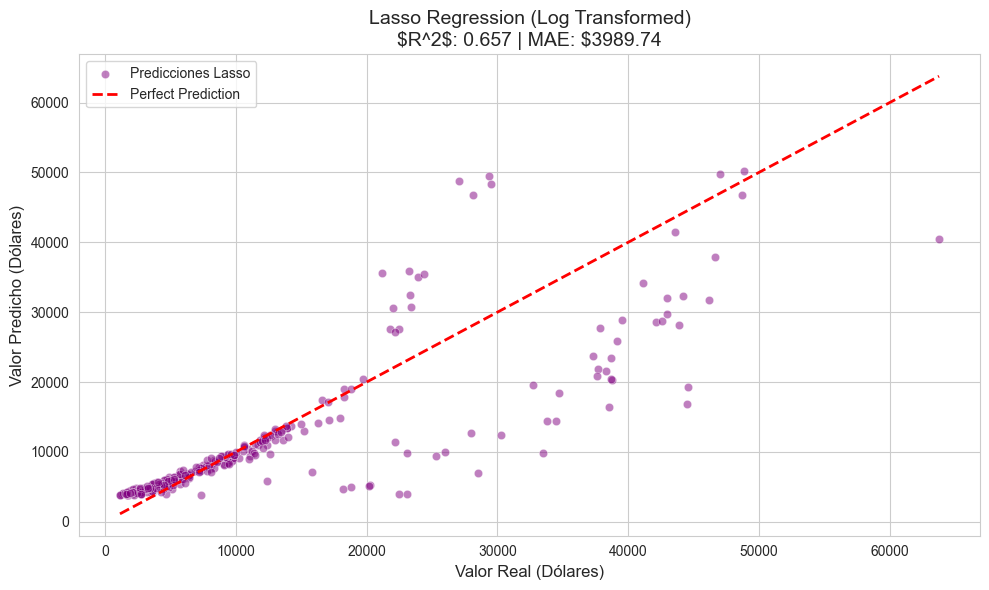

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Calculamos las métricas con los valores revertidos
r2_lasso = r2_score(y_test_out, preds_finales)
mae_lasso = mean_absolute_error(y_test_out, preds_finales)

# 2. Configurar el estilo
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 3. Crear el scatter plot
# Usamos y_test_out (dólares reales) vs preds_finales (dólares predichos)
sns.scatterplot(x=y_test_out, y=preds_finales, alpha=0.5, color="purple", label="Predicciones Lasso")

# 4. Dibujar la línea de referencia (Predicción Perfecta)
line_coords = [y_test_out.min(), y_test_out.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label="Perfect Prediction")
print (r2_lasso, mae_lasso)
# 5. Títulos y etiquetas
plt.title(f"Lasso Regression (Log Transformed)\n$R^2$: {r2_lasso:.3f} | MAE: ${mae_lasso:.2f}", fontsize=14)
plt.xlabel("Valor Real (Dólares)", fontsize=12)
plt.ylabel("Valor Predicho (Dólares)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [229]:
total_data.to_csv('../data/processed/medical_insurance_cost_processed.csv', index = True)
print("Archivo Guardado ")

Archivo Guardado 
